# Multi-Omics Integration for Personalized Medicine Using MOFA

In this notebook, you'll explore a multi-omic dataset of Chronic Lymphocytic Leukemia patients using Multi-Omics Factor Analysis (MOFA) with the MOFA-FLEX package. MOFA-FLEX is a factor model framework that combines functionalities from various previously published methods, including MOFA.

## Prerequisites

Before getting started, ensure that you're familiar with the Python packages used in this tutorial. Below you can find links for short introductions.
- [NumPy](https://numpy.org/doc/2.2/user/quickstart.html)
- [Pandas](https://pandas.pydata.org/docs/user_guide/10min.html)
- [AnnData](https://anndata.readthedocs.io/en/stable/tutorials/notebooks/getting-started.html)
- [ScanPy](https://scanpy.readthedocs.io/en/stable/tutorials/index.html)
- [Plotnine](https://plotnine.org/guide/overview.html) (similar to ggplot2 in R)

In [52]:
import os
import warnings
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import plotnine as p9
import decoupler as dc
from scipy.stats import pearsonr
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns
import mudata as md
import matplotlib.pyplot as plt

import mofaflex as mfl

warnings.filterwarnings("ignore")

In [133]:
import os.path
from tempfile import TemporaryDirectory
from urllib.request import urlretrieve

import anndata as ad
import mofaflex as mfl
import mudata as md
import numpy as np
import pandas as pd
import rdata
import scanpy as sc
from plotnine import *


## Loading and Examining the Data

The data consists of measurements of four modalities:
- In vitro drug response
- Methylation
- mRNA
- Somatic mutations

The data has already been prepared and is available as `.h5mu` files, which you can load using MuData's `read_h5mu` function. This gives you a MuData object for multi-modal data.

In [180]:
mdata = md.read_h5mu("data/cll.h5mu")

### Exercise
1. Explore the different modalities. How many observations and variables do they have? Are the variables shared?
2. Get a feeling for the values in the individual modalities. It's always a good idea to plot their distribution. Why? When would you have to apply further preprocessing before continuing with the actual analysis?

In [55]:
mdata

MuData object with n_obs × n_vars = 200 × 9627
  4 modalities
    drugs:	184 × 310
      obs:	'Gender', 'age', 'TTT', 'TTD', 'treatedAfter', 'died', 'IGHV', 'trisomy12'
    methylation:	196 × 4248
      obs:	'Gender', 'age', 'TTT', 'TTD', 'treatedAfter', 'died', 'IGHV', 'trisomy12'
    mrna:	136 × 5000
      obs:	'Gender', 'age', 'TTT', 'TTD', 'treatedAfter', 'died', 'IGHV', 'trisomy12'
      var:	'gene_name'
    mutations:	200 × 69
      obs:	'Gender', 'age', 'TTT', 'TTD', 'treatedAfter', 'died', 'IGHV', 'trisomy12'

In [181]:
mdata.mod["drugs"].var_names[:10]

Index(['D_001_1', 'D_001_2', 'D_001_3', 'D_001_4', 'D_001_5', 'D_002_1',
       'D_002_2', 'D_002_3', 'D_002_4', 'D_002_5'],
      dtype='object', name='dim_0')

In [182]:
mdata.mod["methylation"].var_names[:10]

Index(['cg10146935', 'cg26837773', 'cg17801765', 'cg13244315', 'cg06181703',
       'cg19626656', 'cg15207968', 'cg12755103', 'cg23651812', 'cg14287724'],
      dtype='object', name='dim_0')

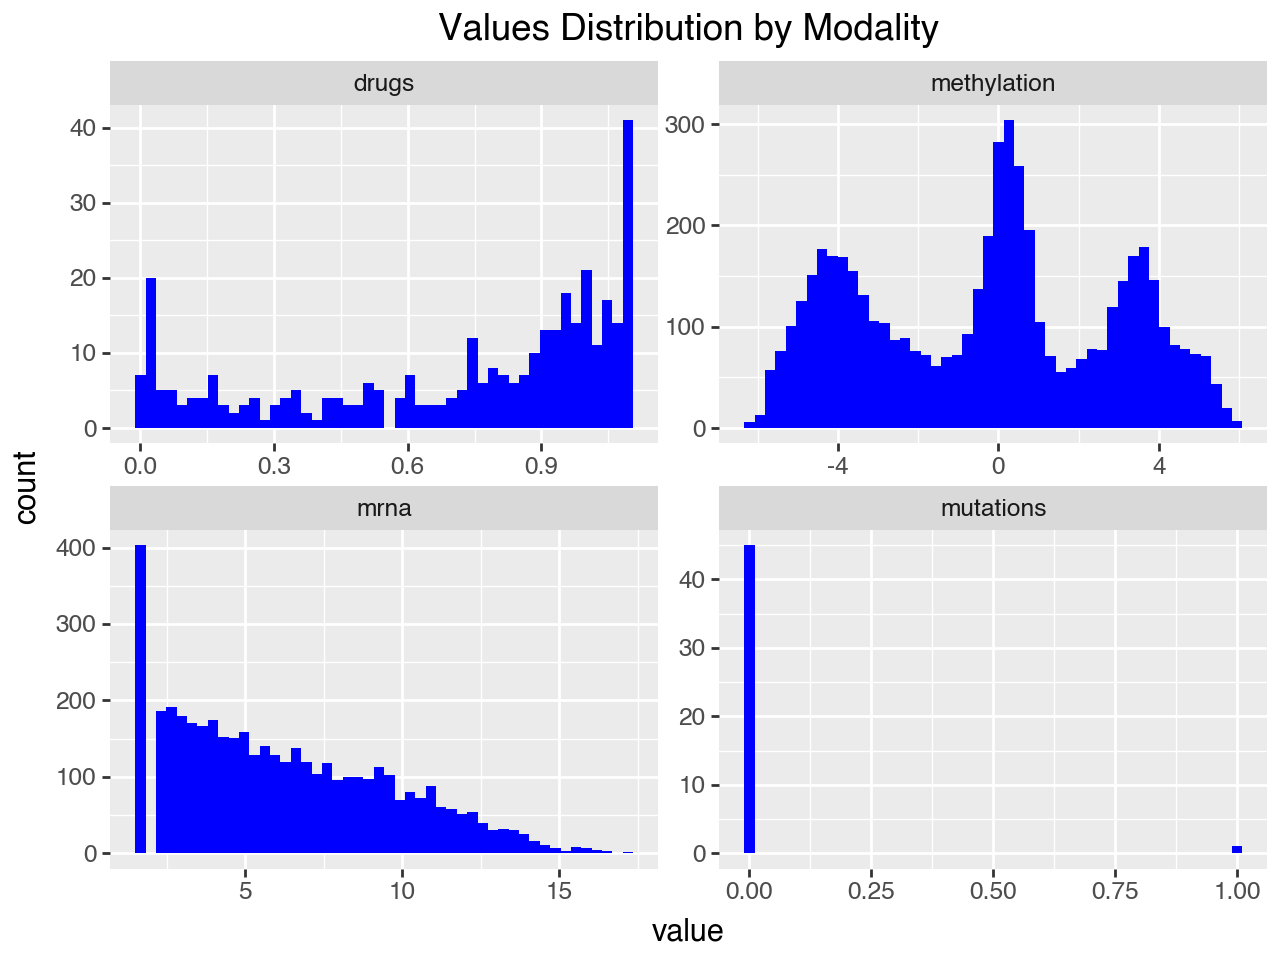

In [183]:
df_plot = pd.concat([
    pd.DataFrame({"value": mdata[mod].X.flatten(), "modality": mod})
    for mod in mdata.mod
]).sample(10000)

plot = (
    p9.ggplot(df_plot, p9.aes(x="value"))
    + p9.geom_histogram(fill="blue")
    + p9.facet_wrap("modality", scales="free")
    + p9.labs(title="Values Distribution by Modality")
)
plot.show()

## Training a MOFA-FLEX Model

MOFA-FLEX can be used in many different configurations and needs to be configured to work well with the specifics of a particular data set. A new MOFA-FLEX model is instantiated and trained using the `mfl.terms.MofaFlex` class. Read more about the different possibilities in the [documentation](https://mofaflex.readthedocs.io/latest/notebooks/getting_started.html).



### Exercise
Train a MOFA-FLEX model on the CLL data. You'll want to use this configuration (everything else should be default values):
- 10 factors
- Horseshoe weight prior
- Normal likelihood for all views
- Training for no more than 10 000 epochs
- Learning rate of 0.05
- Early stopping patience of 1000 epochs
- Save the model with your favourite file name

You'll see that you also get a nice overview of the data structure before training starts.
While the model is training, why don't you have a look into the [original MOFA paper](https://www.embopress.org/doi/full/10.15252/msb.20178124)? Look for the supplementary methods if you're interested in learning more about the statistics involved.

In [184]:
# model = mfl.terms.MofaFlex(n_factors=10, weight_prior="Horseshoe")
# model.fit(mdata, likelihoods="Normal", lr=0.05, early_stopper_patience=1000, max_epochs=10000, save_path="results/model.h5", seed=123)
model = mfl.MOFAFLEX.load("results/model.h5")

One of the first things you'll want to look at after model training has finished is how meaningful the factors are that were found. A good measure for this is the explained variance per factor. It tells you how much of the observed variance in a given view is explained by an individual factor. MOFA-FLEX can create a plot of this quantity with the `mf.pl.variance_explained` function.

Other important checks are the convergence of the training loss curve and the factor correlation. The factor correlation is a cross correlation matrix of individual factors, showing the user how similar the factors are to each other. 

### Exercise
1. Make a variance explained plot and explain what you're seeing!
2. Can you find the relevant functions in `mf.pl` ([documentation](https://mofaflex.readthedocs.io/latest/api.html)) for plotting the training loss curve and the factor correlation? Do the plots look good?

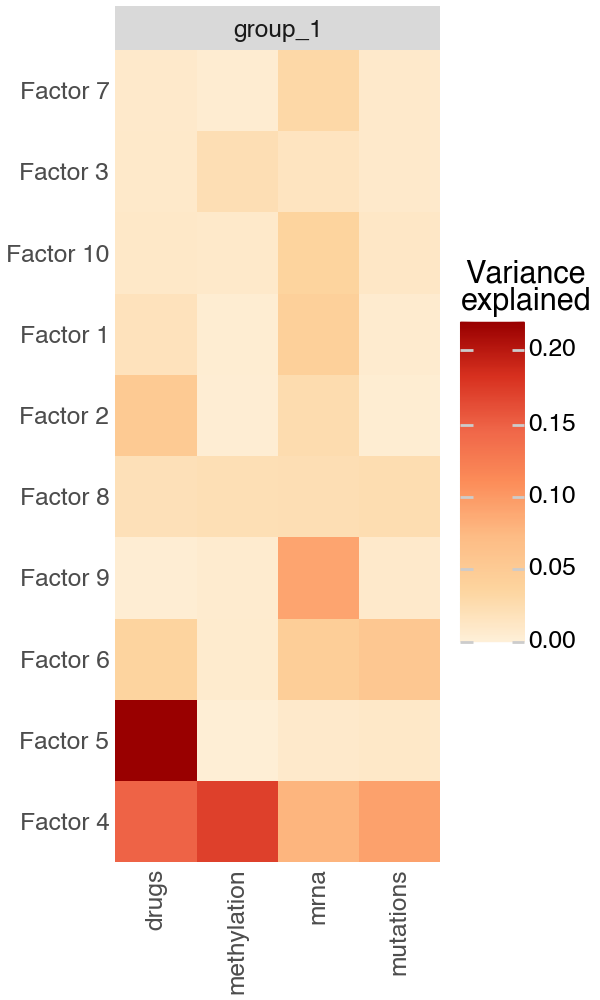

In [185]:
mfl.pl.variance_explained(model)

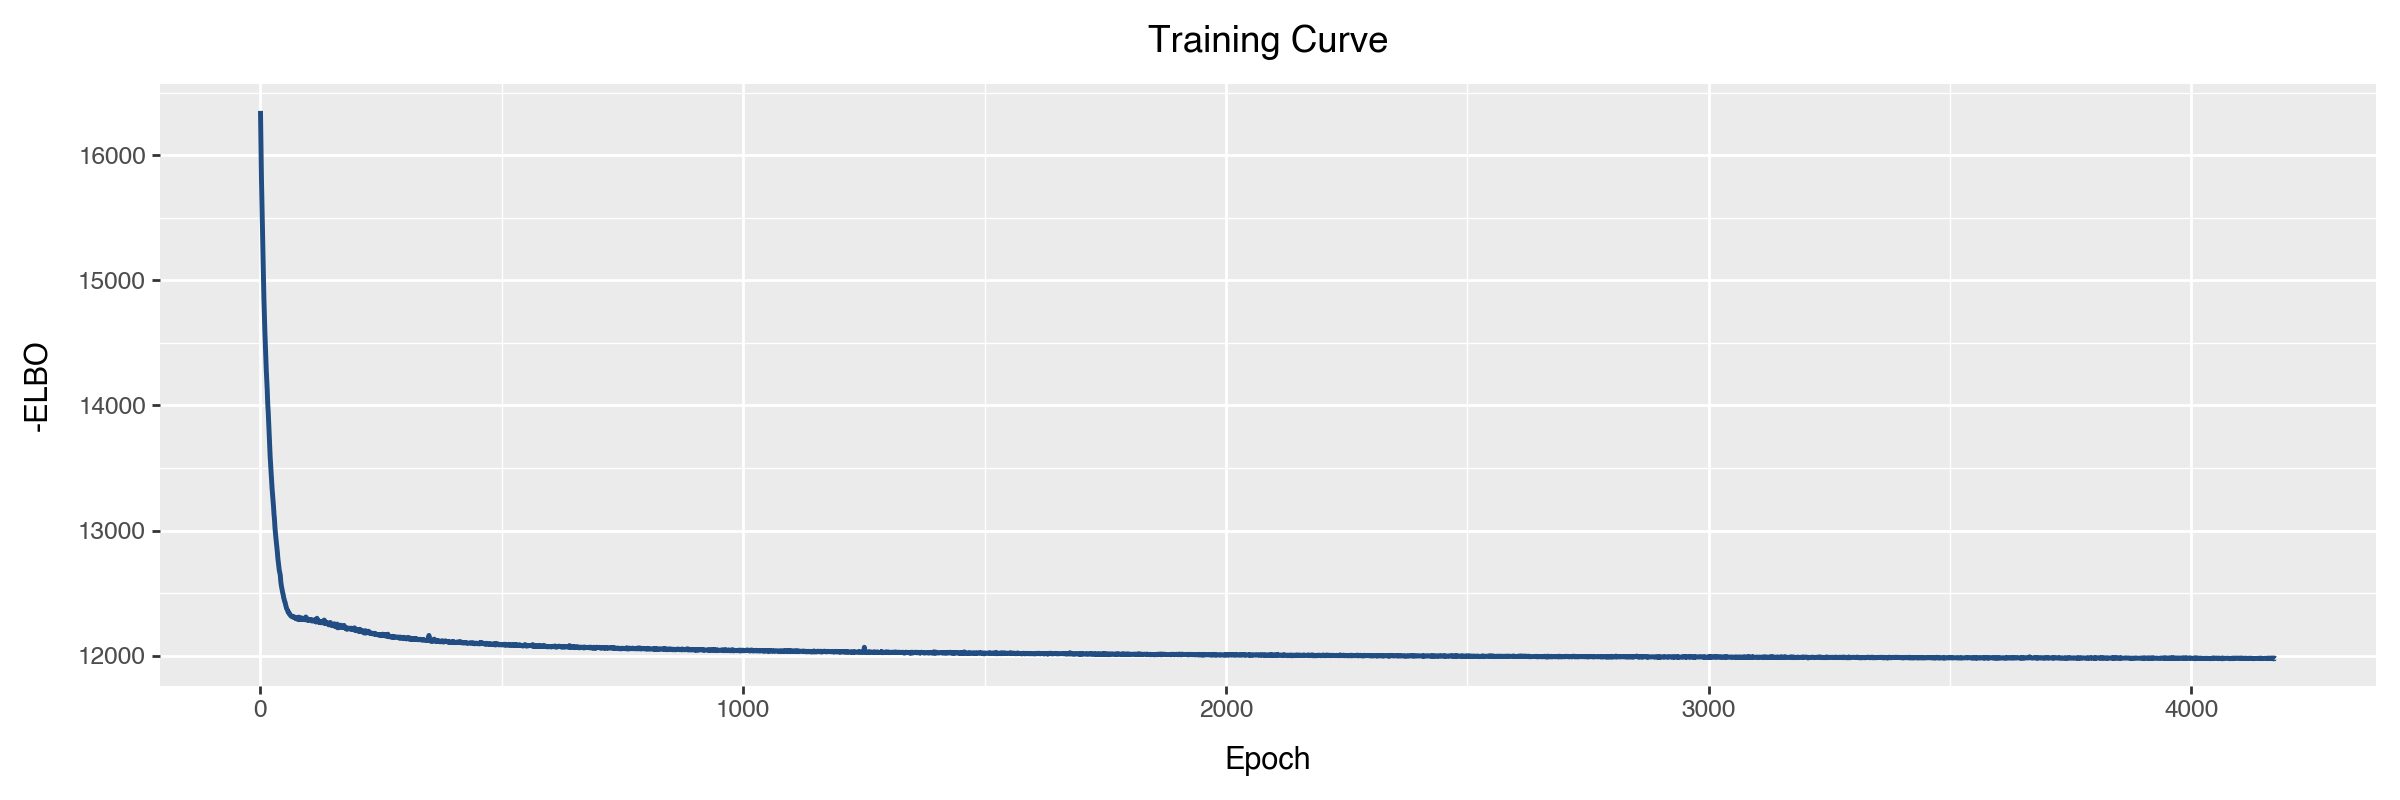

In [186]:
mfl.pl.training_curve(model)

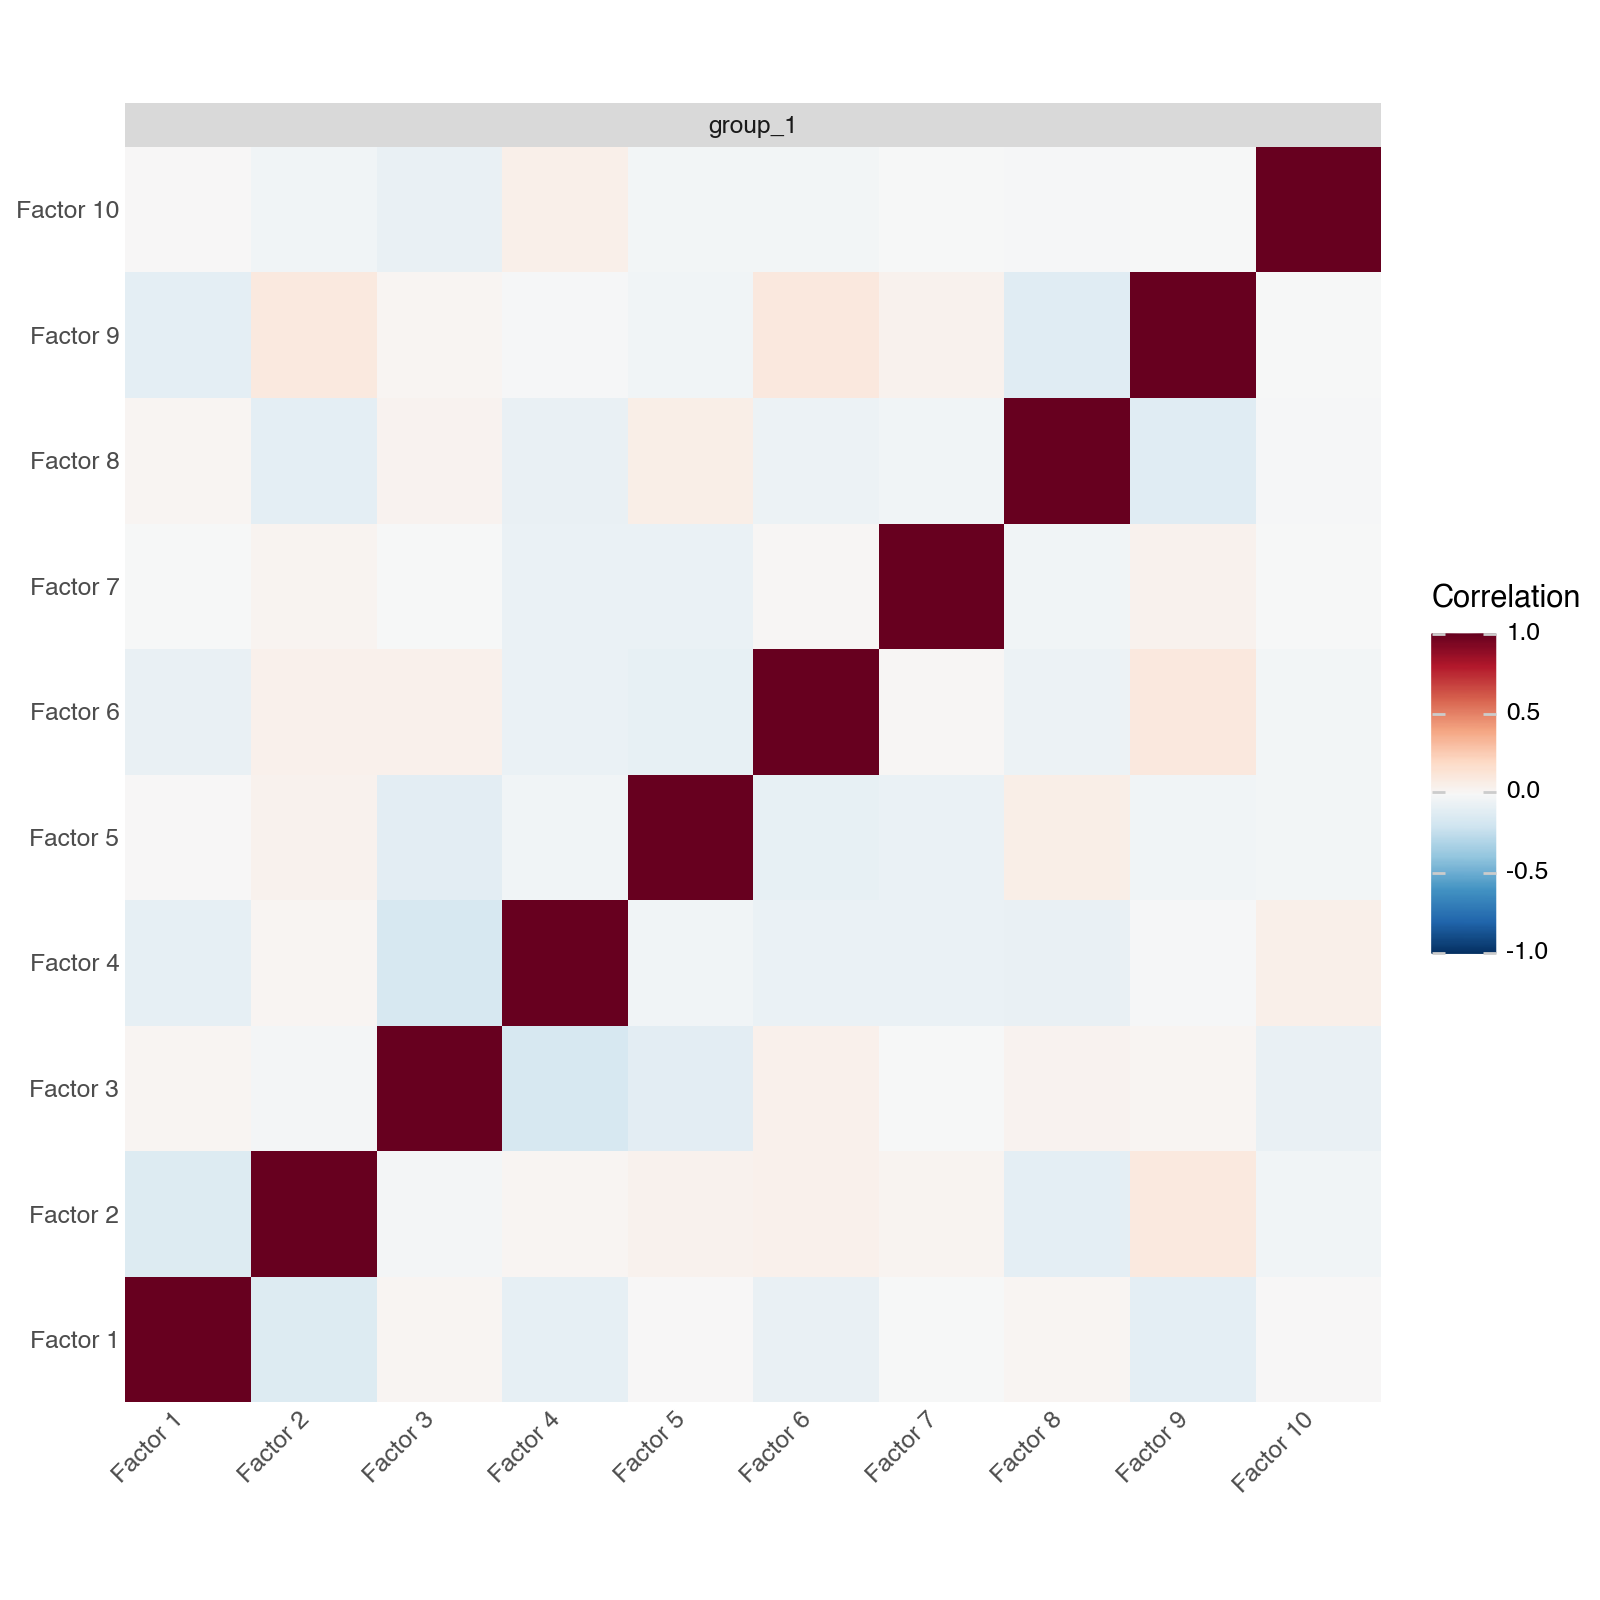

In [187]:
mfl.pl.factor_correlation(model)

## Choosing the right number of factors
The number of factors used in a MOFA-FLEX model is a user choice which can have some influence on the outcome.

### Exercise
1. Train a MOFA-FLEX model with a smaller number of factors and re-do the analysis from above. Make sure to give it another name (and save to another file) to have access to both models afterwards. Do you see any difference?
2. What could be consequences of choosing too many or too few factors?

In [188]:
# model_small = mfl.terms.MofaFlex(n_factors=5, weight_prior="Horseshoe")
# model_small.fit(data, likelihoods="Normal", lr=0.05, early_stopper_patience=1000, max_epochs=10000, save_path="results/model_small.h5", seed=1234)
model_small = mfl.MOFAFLEX.load("results/model_small.h5")

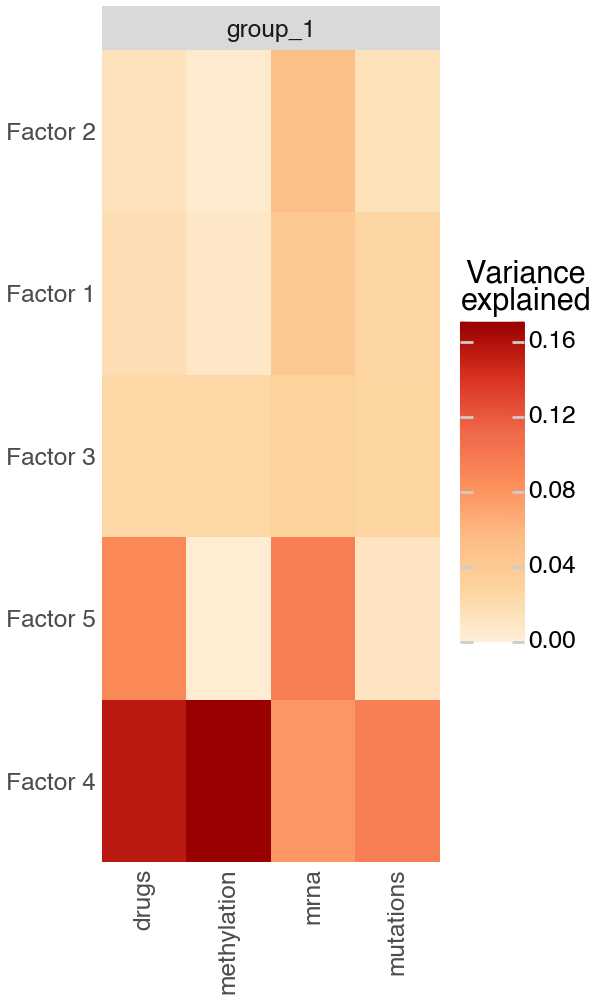

In [189]:
mfl.pl.variance_explained(model_small)

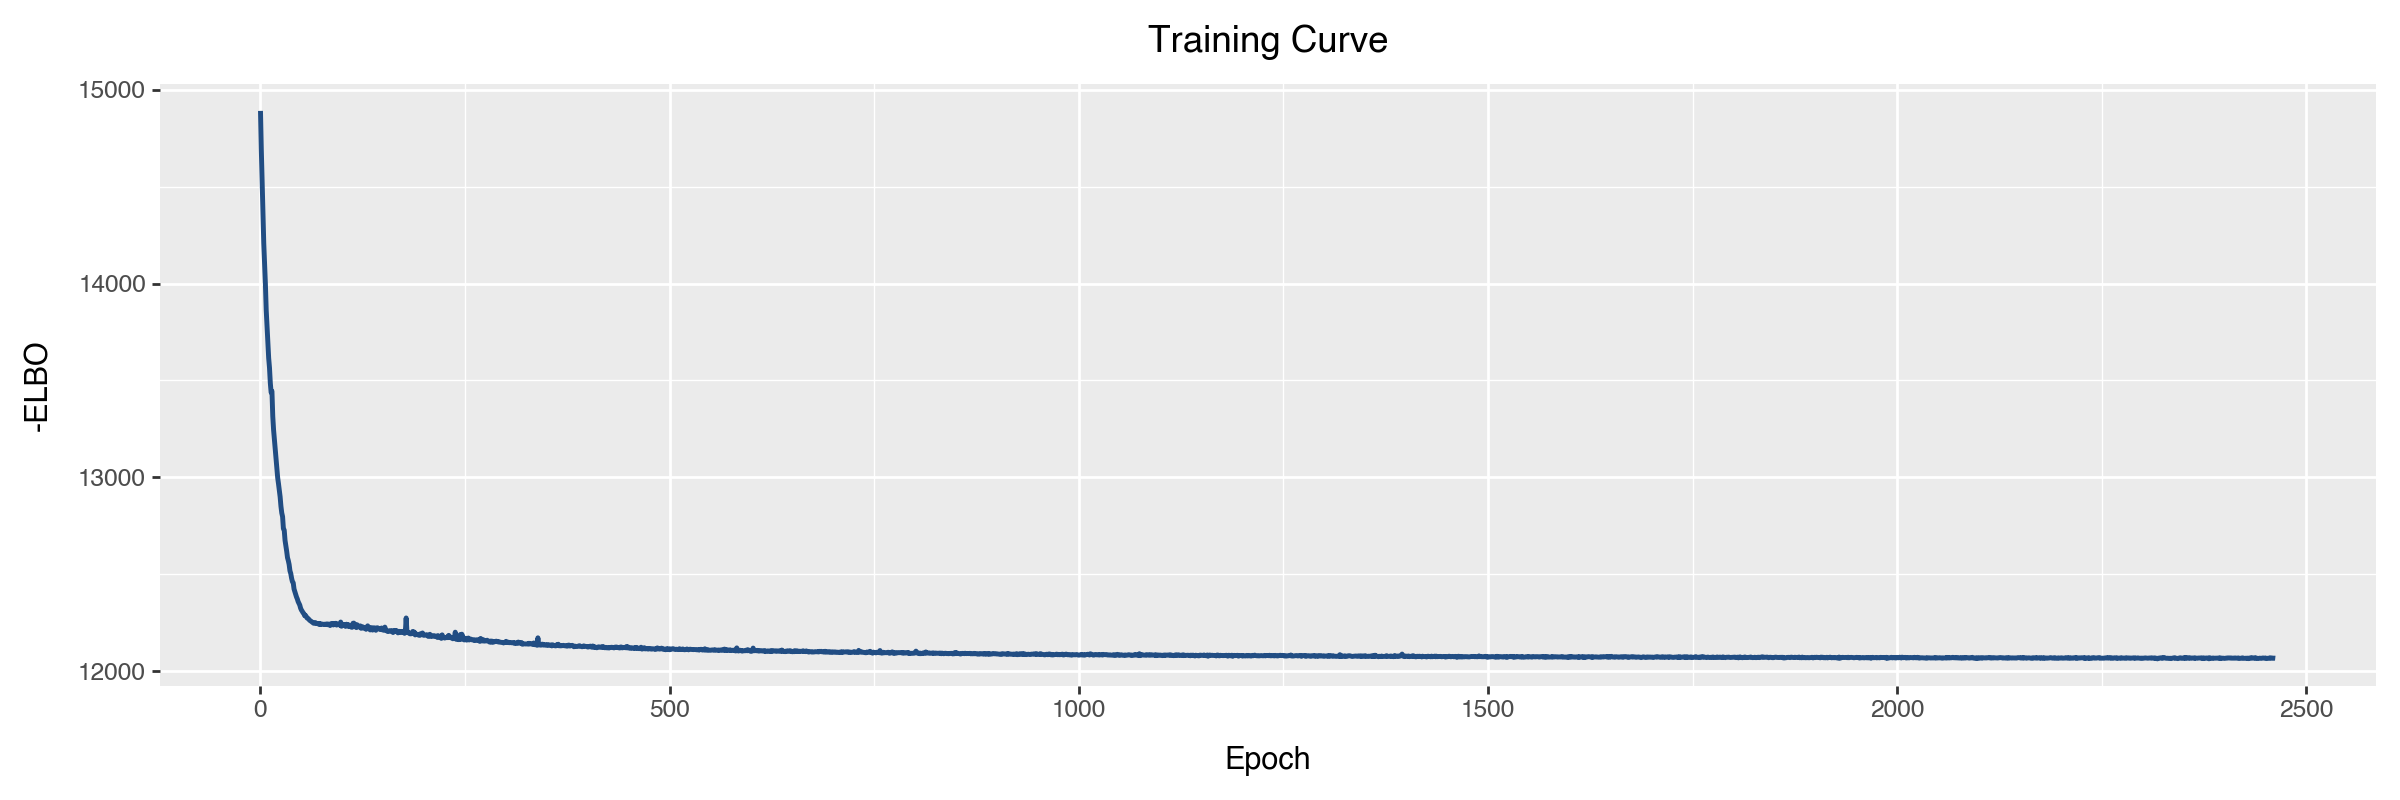

In [190]:
mfl.pl.training_curve(model_small)

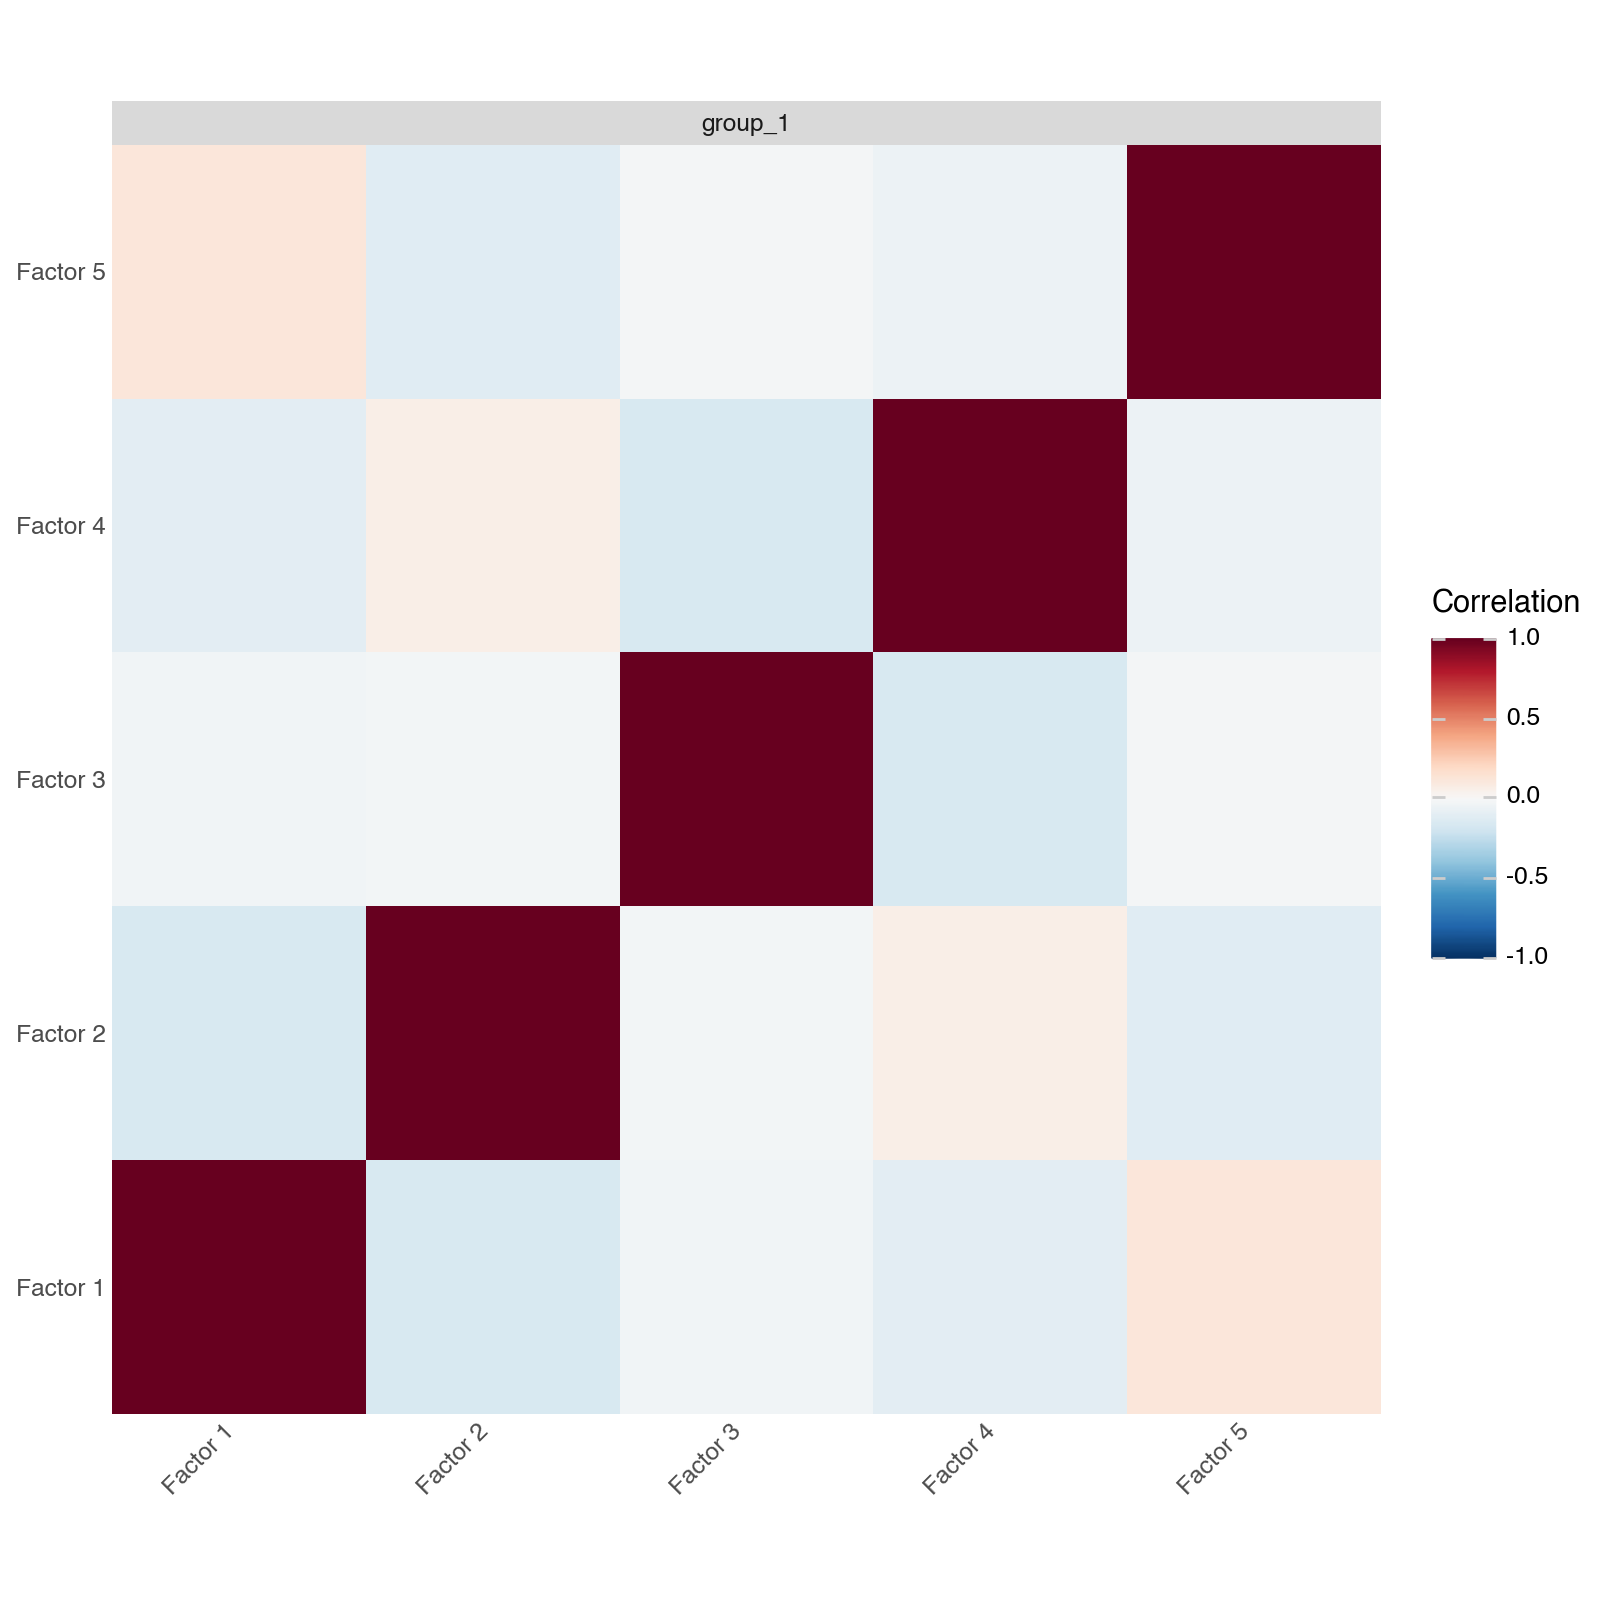

In [191]:
mfl.pl.factor_correlation(model_small)

## Examining the factor weights and scores of the trained model

Now we'll want to have a closer look at the two main results of a MOFA-FLEX analysis:
1. Factor scores (matrix of shape `(n_observations, n_factors)`), representing the activity of individual factors in each observation.
2. Factor weights (matrix of shape `(n_variables, n_factors)`), linking the low-dimensional factors to the high-dimensional original variables (e.g. genes). There is one weights matrix for each modality.

We're sometimes a bit sloppy with the language and refer to the factors scores simply as "factors", and to the factor weights as "weights".

### Exercise
1. The factor scores and weights are obtained from the MOFA-FLEX model instance using the `.get_factors()` and `.get_weights()` methods, respectively. Try this out and validate the dimensions of the factor scores. Why do you get dictionaries from these methods and how are they structured?
2. To get a very quick overview, make heatmaps of the different matrices. There is no inbuilt method for this (use plotnine or your favourite plotting library).

In [192]:
factors = model.get_factors()
weights = model.get_weights()

print("Factors shape: ", factors["group_1"].shape)
print("Weights (Drugs) shape: ", weights["drugs"].shape)
print("Weights (Methylation) shape: ", weights["methylation"].shape)
print("Weights (mRNA) shape: ", weights["mrna"].shape)
print("Weights (Mutations) shape: ", weights["mutations"].shape)

Factors shape:  (200, 10)
Weights (Drugs) shape:  (310, 10)
Weights (Methylation) shape:  (4248, 10)
Weights (mRNA) shape:  (5000, 10)
Weights (Mutations) shape:  (69, 10)


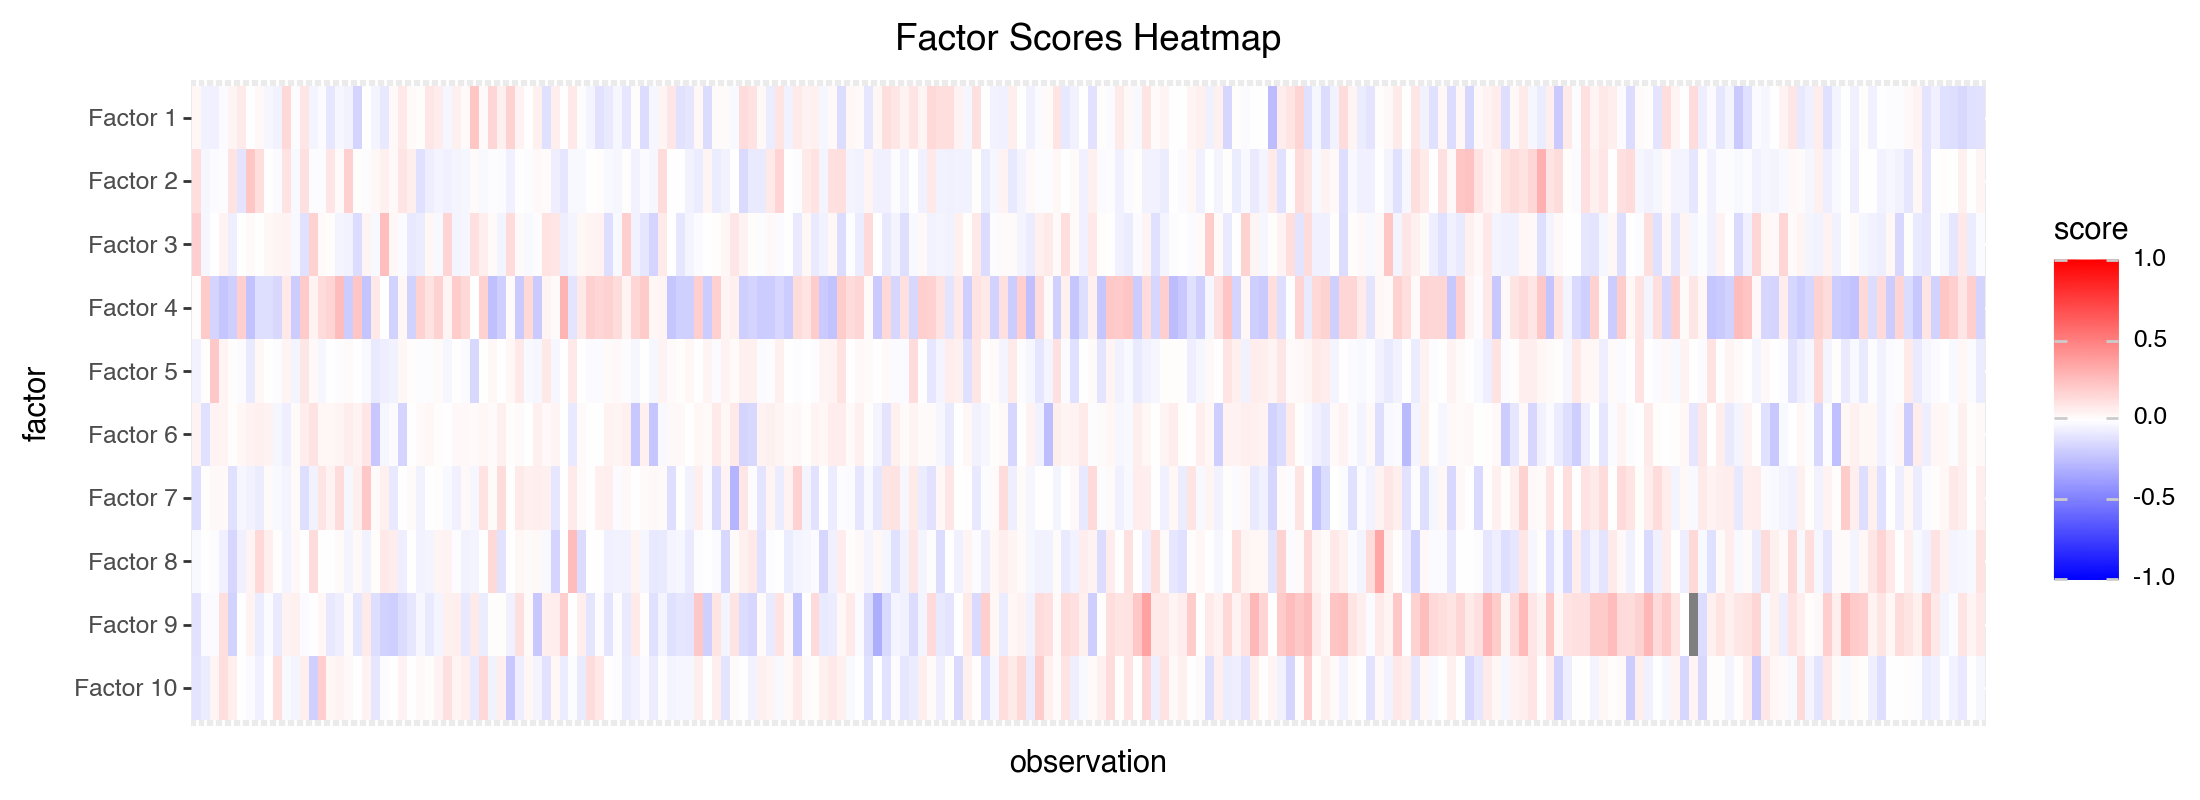

In [193]:
df_plot = factors["group_1"].reset_index(names="observation").melt(id_vars="observation", var_name="factor", value_name="score")
df_plot["factor"] = pd.Categorical(df_plot["factor"], categories=[f"Factor {i}" for i in range(1, 11)][::-1], ordered=True)

plot = (
    p9.ggplot(df_plot, p9.aes(x="observation", y="factor", fill="score"))
    + p9.geom_tile()
    + p9.scale_fill_gradient2(low="blue", mid="white", high="red", midpoint=0, limits=[-1, 1])
    + p9.theme(figure_size=(11, 4), axis_text_x=p9.element_blank(), axis_ticks_x=p9.element_blank())
    + p9.labs(title="Factor Scores Heatmap")
)
plot.show()

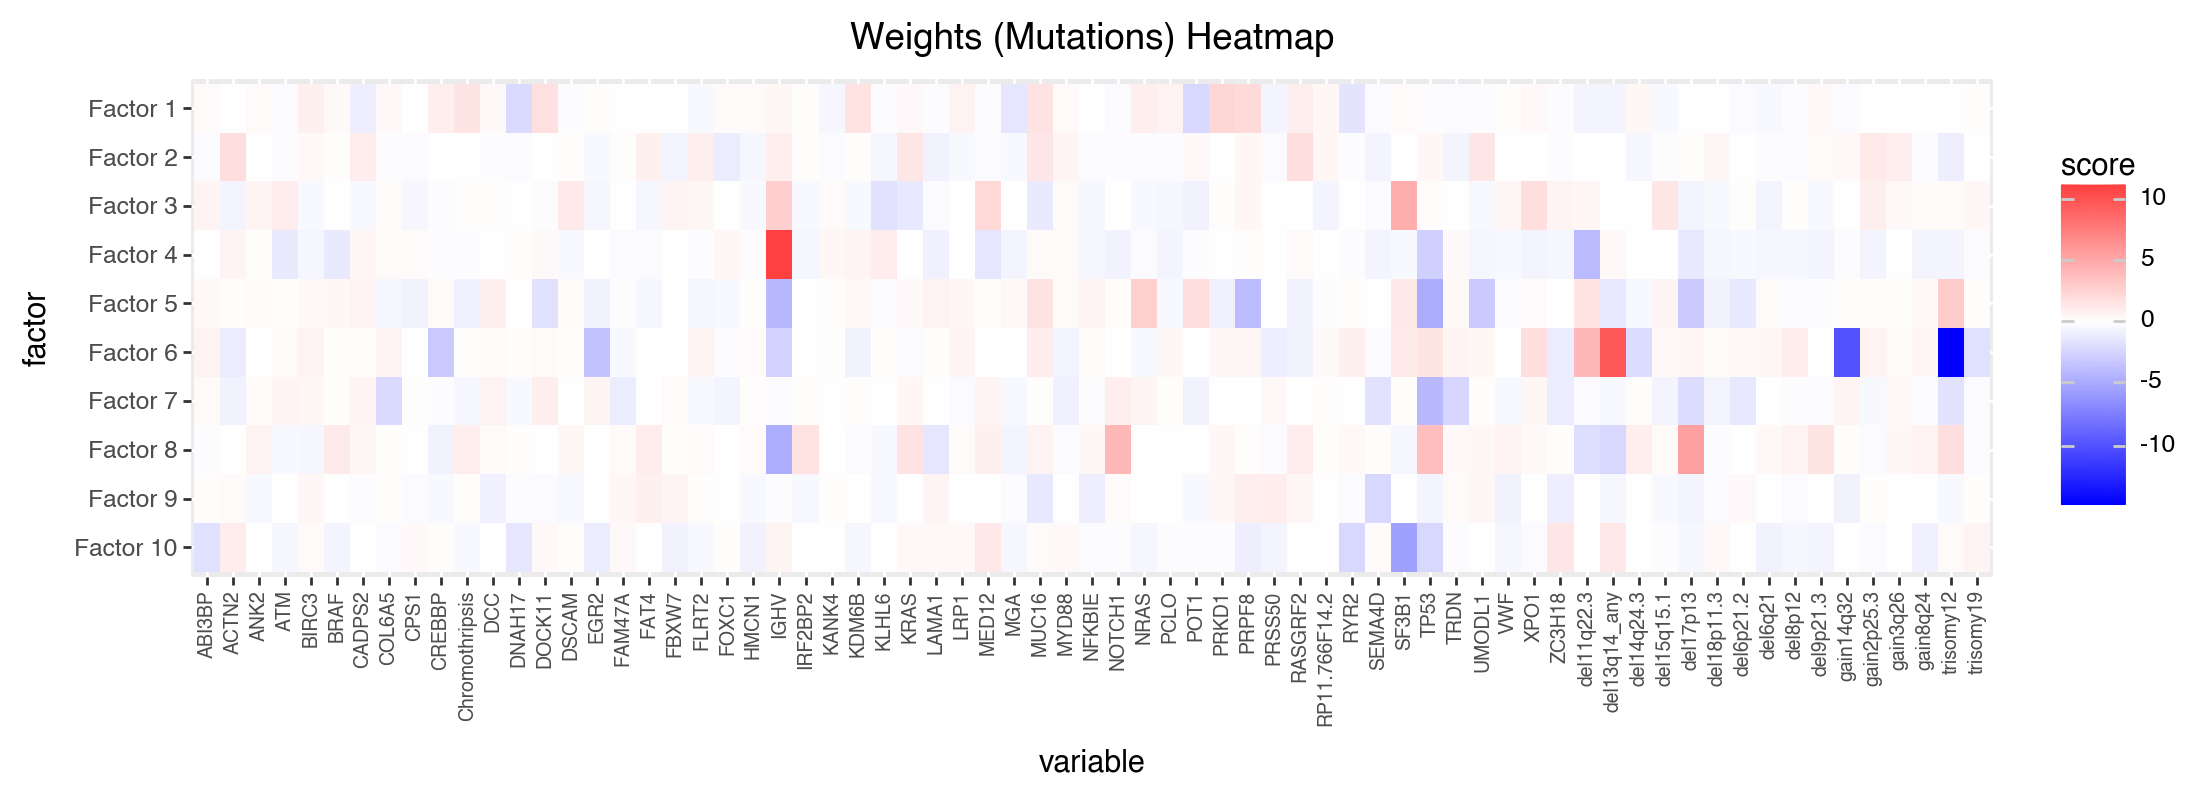

In [194]:
df_plot = weights["mutations"].reset_index(names="variable").melt(id_vars="variable", var_name="factor", value_name="score")
df_plot["factor"] = pd.Categorical(df_plot["factor"], categories=[f"Factor {i}" for i in range(1, 11)][::-1], ordered=True)

plot = (
    p9.ggplot(df_plot, p9.aes(x="variable", y="factor", fill="score"))
    + p9.geom_tile()
    + p9.scale_fill_gradient2(low="blue", mid="white", high="red", midpoint=0)
    + p9.theme(
        axis_text_x=p9.element_text(rotation=90, hjust=.5, size=7),
        figure_size=(11, 4),
    )
    + p9.labs(title="Weights (Mutations) Heatmap")
)
plot.show()

### Exercise

You have now trained two MOFA-FLEX models, one with 10 factors and one with a smaller number. How similar are inidividual factors (in terms of their factor scores) between those two? To find this out, compute the Pearson correlation coefficient for each possible combination of factors across models to create a correlation matrix (shape `10 x smaller number of factors`). What do you see and does this match your expectations?

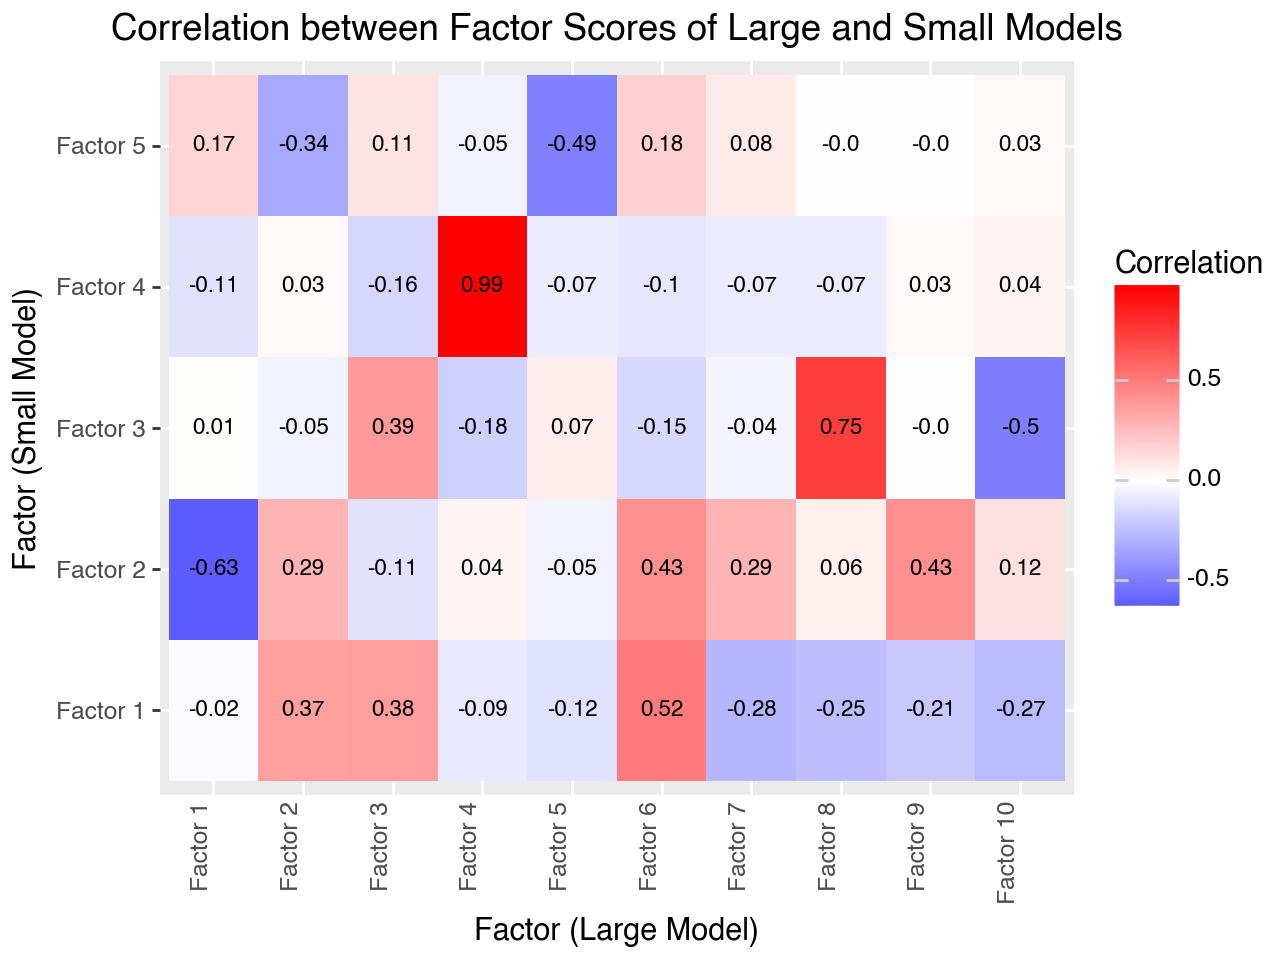

In [195]:
corr_matrix = np.zeros((model.n_factors, model_small.n_factors))

for factor in range(model.n_factors):
    for factor_small in range(model_small.n_factors):
        corr_matrix[factor, factor_small] = pearsonr(
            model.get_factors()["group_1"].iloc[:, factor],
            model_small.get_factors()["group_1"].iloc[:, factor_small],
        )[0]

df_plot = pd.DataFrame(
    corr_matrix,
    columns=[f"Factor {i+1}" for i in range(model_small.n_factors)],
    index=[f"Factor {i+1}" for i in range(model.n_factors)],
    ).reset_index(names="Factor").melt(id_vars="Factor", var_name="Factor Small", value_name="Correlation")
df_plot["Correlation"] = np.round(df_plot["Correlation"], 2)
df_plot["Factor"] = pd.Categorical(df_plot["Factor"], categories=[f"Factor {i+1}" for i in range(model.n_factors)], ordered=True)

plot = (
    p9.ggplot(df_plot, p9.aes(x="Factor", y="Factor Small", fill="Correlation"))
    + p9.geom_tile()
    + p9.scale_fill_gradient2(low="blue", mid="white", high="red", midpoint=0)
    + p9.theme(axis_text_x=p9.element_text(rotation=90, hjust=1), axis_ticks_x=p9.element_blank())
    + p9.labs(
        title="Correlation between Factor Scores of Large and Small Models",
        x="Factor (Large Model)",
        y="Factor (Small Model)",
    )
    + p9.geom_text(p9.aes(label="Correlation"), color="black", size=8)
)
plot.show()

### Exercise

Let's now look at the factor scores more closely. We are interested in the question whether any of the factors separates certain groups of patients. The easiest way to see this is to make box or violin plots with separate boxes / violins for different groups. Hint: Check the IGHV and Trisomy12 status, which you can obtain e.g. from `mdata.obs["drugs:IGHV"]` and `mdata.obs["drugs:trisomy12"]` (the modality does not matter). You can get the factor scores using `model.get_factors()["group_1"]`.

In [214]:
plot_df = (
    model.get_factors()["group_1"]
    .join(mdata.obs[["IGHV", "trisomy12"]])
    .reset_index(names="Observation")
    .melt(id_vars=["Observation", "IGHV", "trisomy12"], var_name="Factor", value_name="Score")
    )

plot_df = plot_df[(~plot_df["IGHV"].isna()) & ~(plot_df["trisomy12"].isna())]
plot_df["IGHV"] = pd.Categorical(plot_df["IGHV"])
plot_df["trisomy12"] = pd.Categorical(plot_df["trisomy12"])
plot_df["Factor"] = pd.Categorical(plot_df["Factor"], categories=[f"Factor {i}" for i in range(1, 11)])

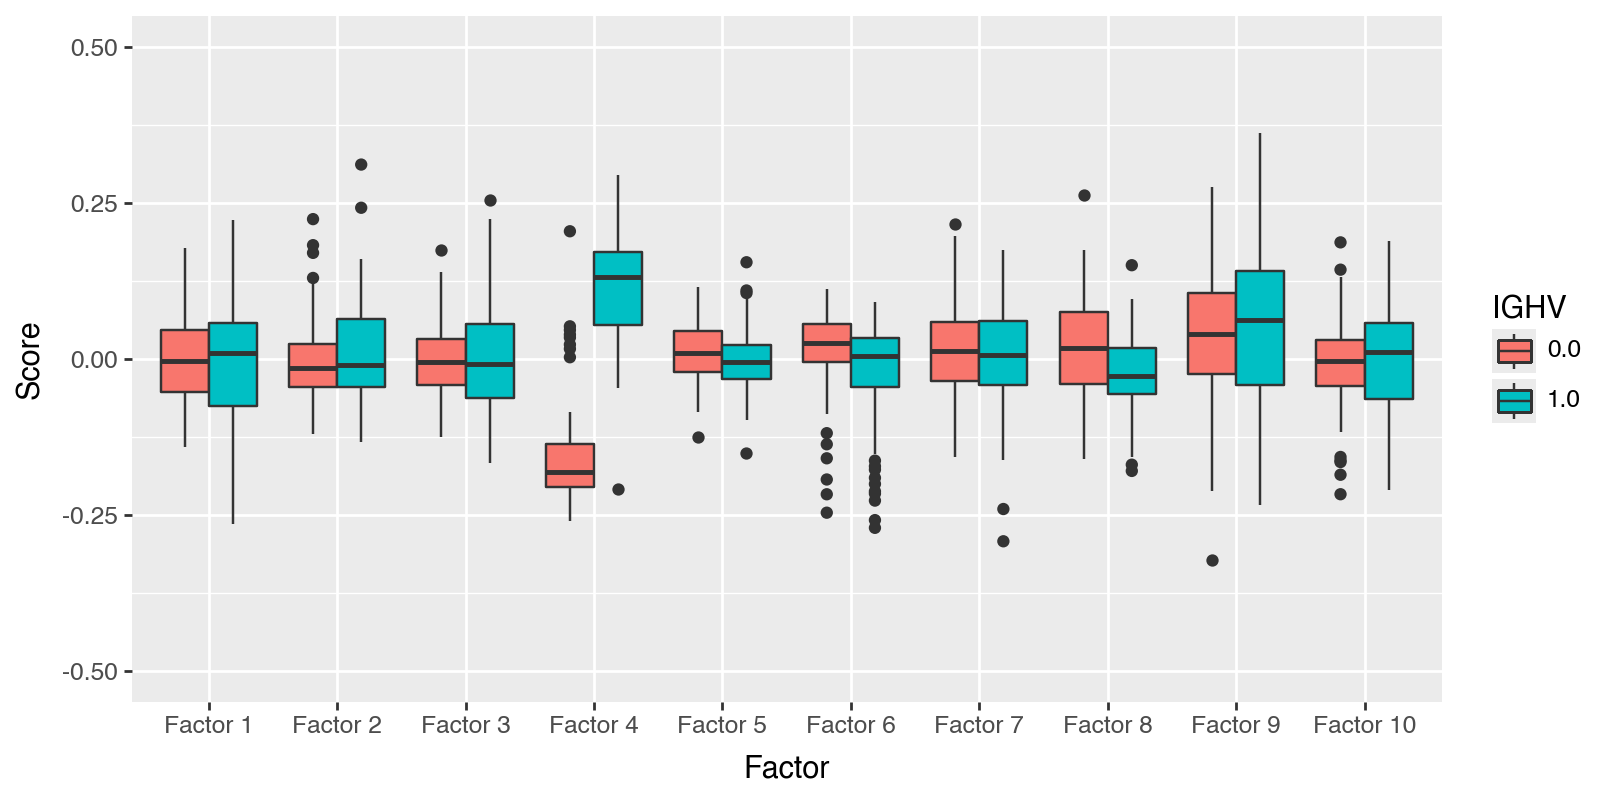

In [215]:
plot = (
    p9.ggplot(plot_df, p9.aes(x="Factor", y="Score", fill="IGHV"))
    + p9.geom_boxplot(position="dodge")
    + p9.ylim(-.5, .5)
    + theme(figure_size=(8, 4))
)
plot.show()

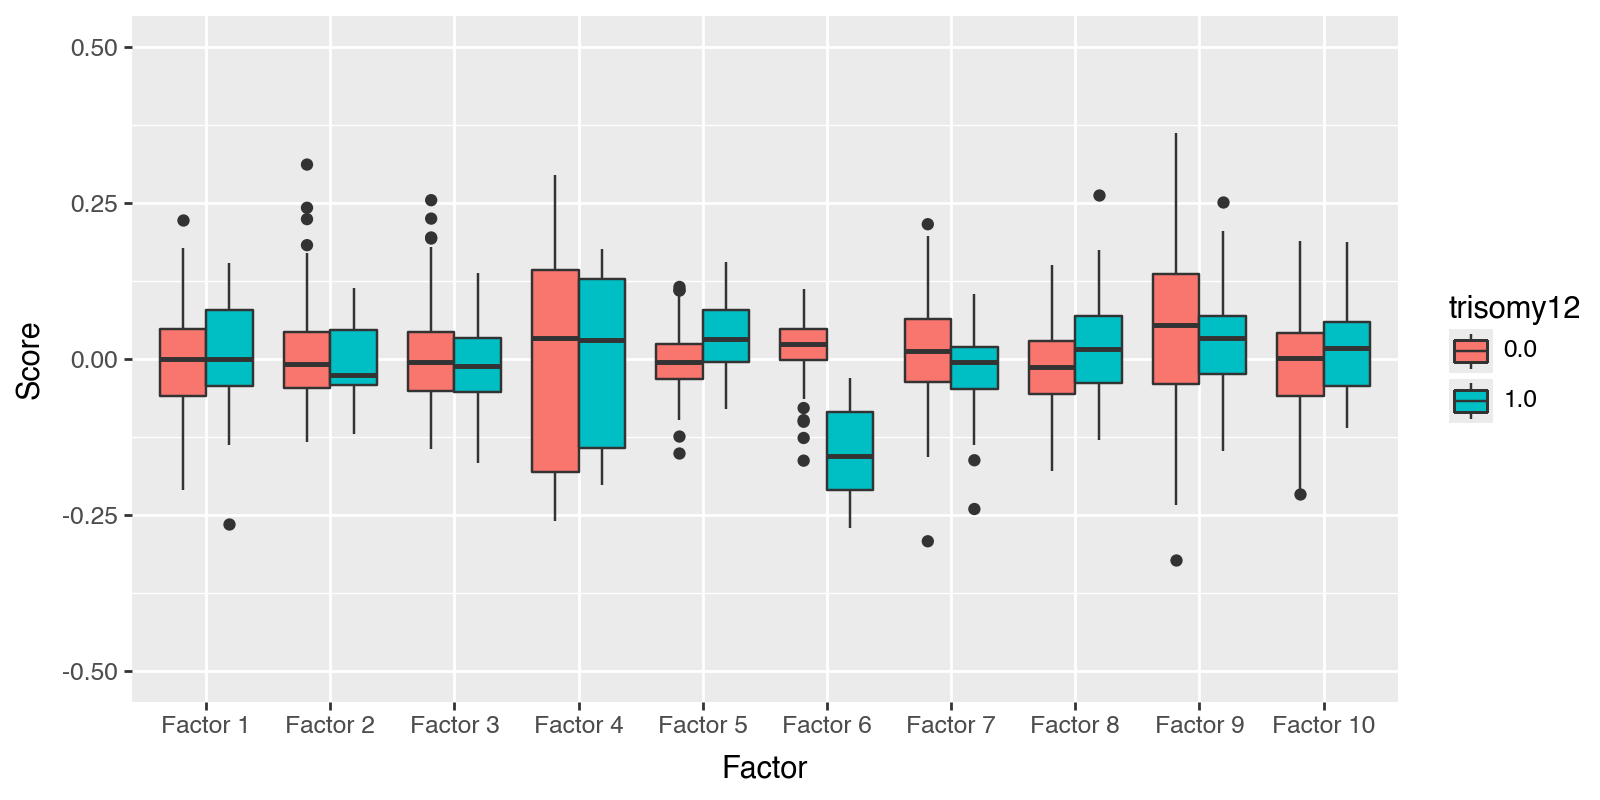

In [216]:
plot = (
    p9.ggplot(plot_df, p9.aes(x="Factor", y="Score", fill="trisomy12"))
    + p9.geom_boxplot(position="dodge")
    + p9.ylim(-.5, .5)
    + theme(figure_size=(8, 4))
)
plot.show()

Now try to make a scatterplot with one of the relevant factors on the x and the other factor on the y axis. Use color / shape to denote patients with different IGHV and trisomy12 status. Can you see how this stratifies patients into four groups?

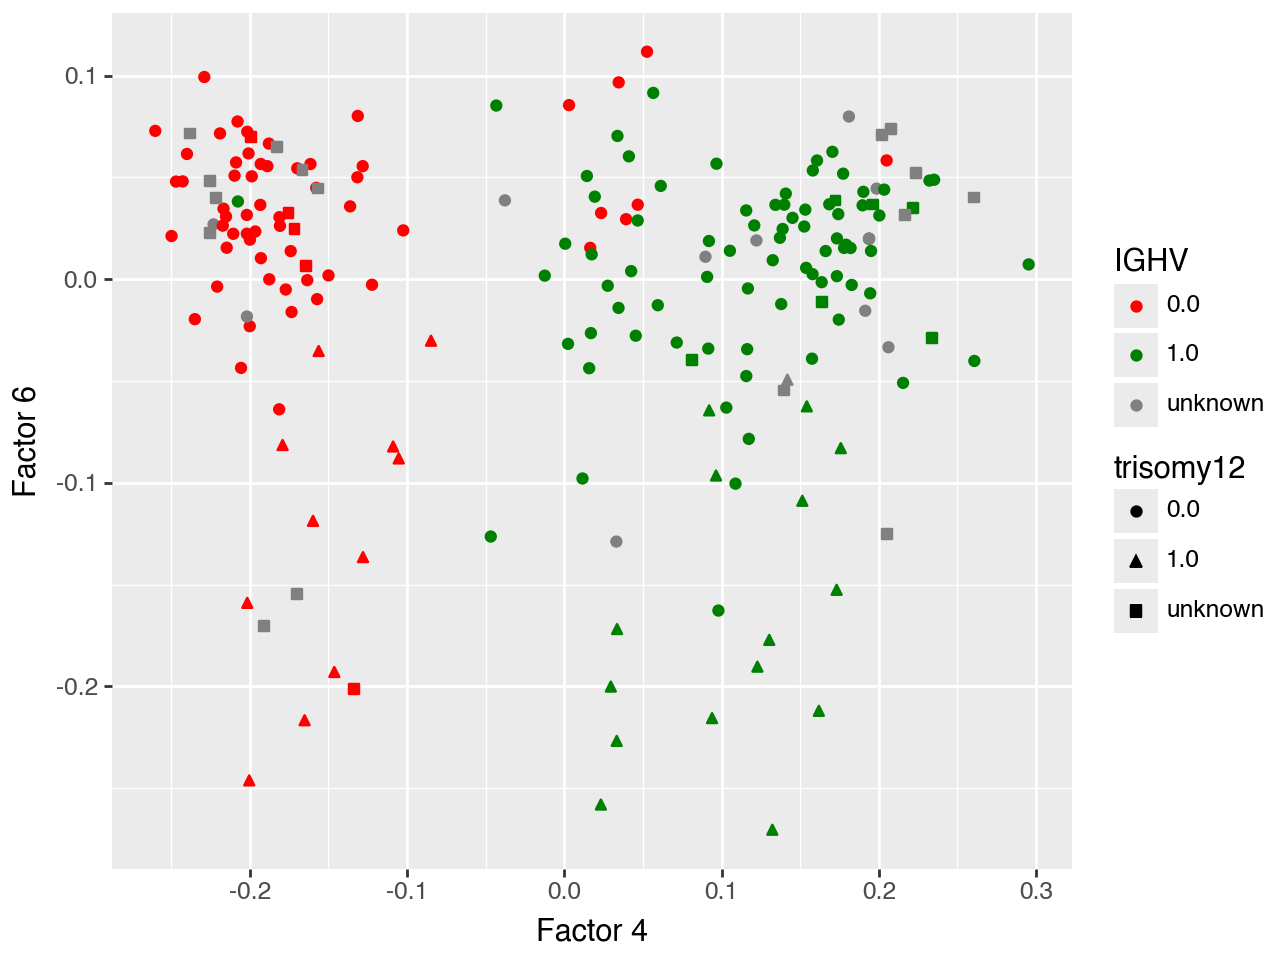

In [236]:
plot_df = (
    model.get_factors()["group_1"]
    .join(mdata.obs[["IGHV", "trisomy12"]])
    .reset_index(names="Observation")
    )

plot_df["IGHV"] = pd.Categorical(plot_df["IGHV"].astype(str).replace("nan", "unknown"))
plot_df["trisomy12"] = pd.Categorical(plot_df["trisomy12"].astype(str).replace("nan", "unknown"))

plot = (
    ggplot(plot_df, aes(x="Factor 4", y="Factor 6", color="IGHV", shape="trisomy12"))
    + geom_point()
    + scale_color_manual({"0.0": "red", "1.0": "green", "unknown": "grey"})
)
plot.show()

### Exercise

You have probably seen that not all patients have known IGHV status (they just have a NaN in the corresponding column). However, you just found a factor that separates patients by their IGHV status! How about predicting IGHV status for the missing patients from the factor scores of this factor? Use a simple classification algorithm from scikit-learn, such as `KNeighborsClassifier`. This algorithm takes as input the factor scores for the relevant factor and decides for each of the missing patients based on a majority vote of the surrounding patients (surrounding means closest factor scores). Hint: Use only the patients with known IGHV status as a training set, and then predict IGHV status on the full data set.

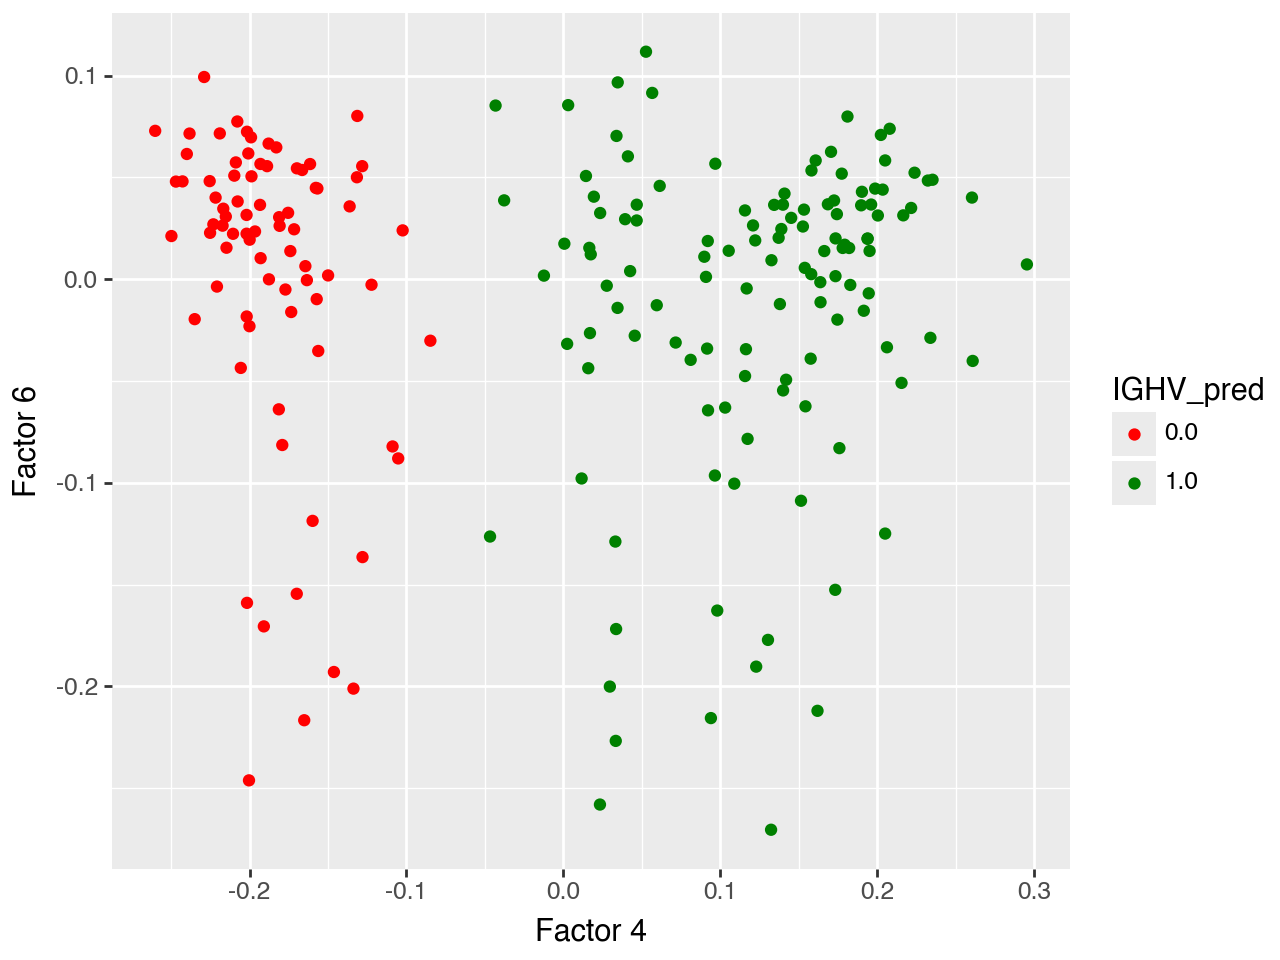

In [234]:
factors = model.get_factors()["group_1"]
ighv_label = mdata.obs["IGHV"]

train_inds = ighv_label.notna()

X = factors.loc[:, "Factor 4"].values.reshape(-1, 1)
X_train = X[train_inds]
y_train = ighv_label.loc[train_inds]

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X)

df_plot = factors.copy()
df_plot["IGHV_pred"] = y_pred
df_plot["IGHV_pred"] = pd.Categorical(df_plot["IGHV_pred"])

plot = (
    p9.ggplot(df_plot, p9.aes(x="Factor 4", y="Factor 6", color="IGHV_pred"))
    + p9.geom_point()
    + scale_color_manual({0.0: "red", 1.0: "green"})
)
plot.show()

Now that you found which factors stratify the patients into several groups, you should have a closer look at the corresponding factor weights. The weights describe how each original variable (gene, methylation site, ...) is associated with an individual factor. Also note that both the factor scores and weights can be positive or negative. Switching the signs of both the scores and the weights for a factor will not make a difference because the $-1 * -1 = 1$. But in general, the sign is important because it tells us about the direction of an effect. For example, if the sign of the factor weights for gene A is positive, and for gene B is negative, an increased activity (as measured by the factor score) of this factor in a given sample has opposite effects on the values of those genes in the data.

## Exercise
Use the `mf.pl.top_weights` function to plot the highest (absolute) weights of the factor that you found to separate patients by IGHV status. Plot the weights for the different modalities (views). What can you conclude about e.g. a drug with a high weight in the drugs view? How is it related to IGHV status and can you make predictions about drug efficacy from this? What role does the sign of the weight play?

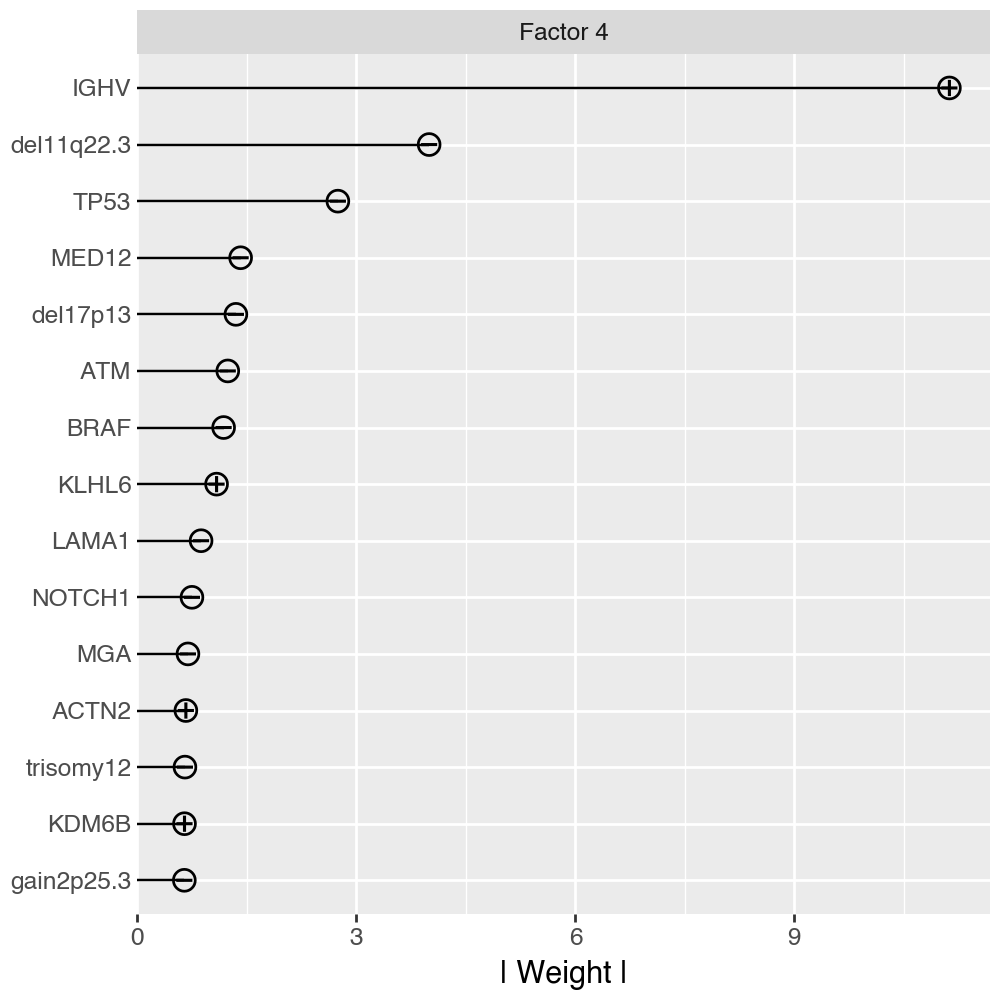

In [240]:
mfl.pl.top_weights(model, 15, "mutations", "Factor 4")

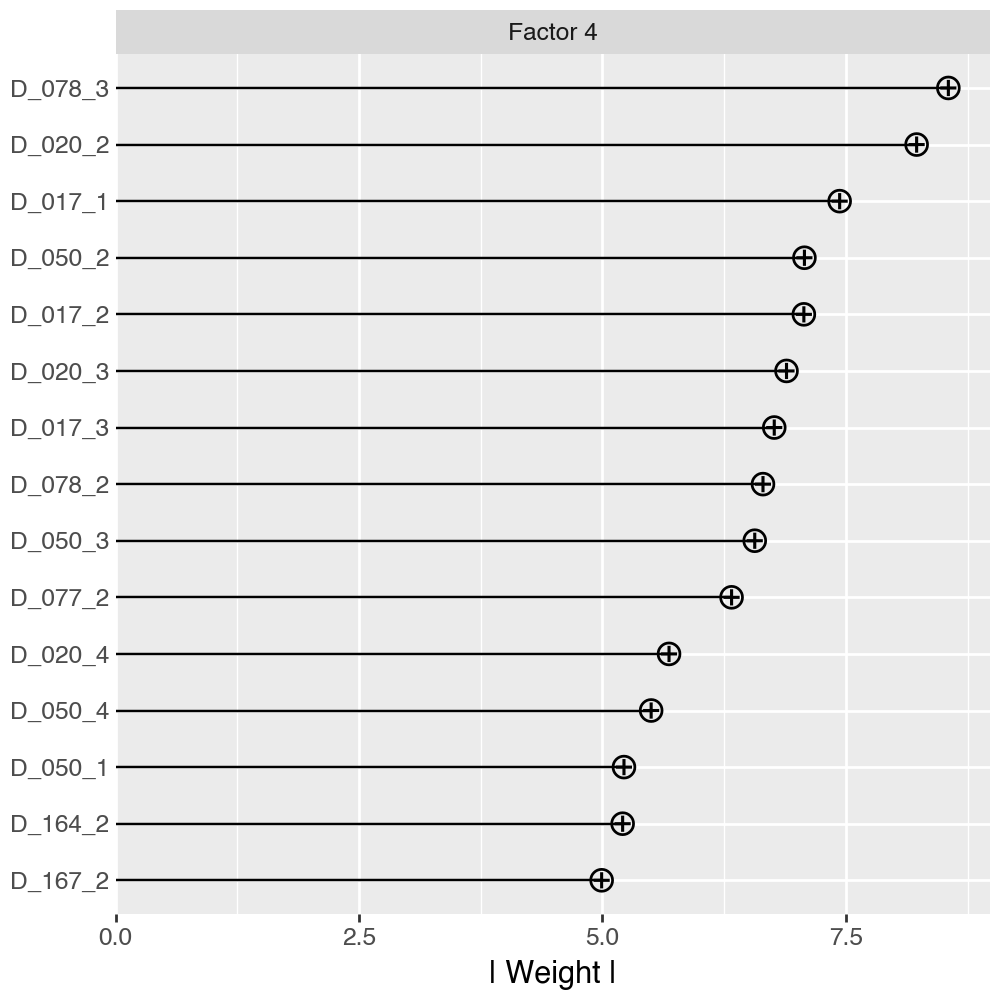

In [241]:
mfl.pl.top_weights(model, 15, "drugs", "Factor 4")

Finally, we want to try assigning biological meaning to the factors that we found. This could e.g. be a pathway that comprises a number of the original data variables. This is done by looking at the factor weights. For each factor, we can perform a gene set enrichment analysis.

### Exercise
Use the decoupler package to run a gene set enrichment analysis with the "Hallmark" gene sets. Do you find any significant hits?

In [243]:
# load the data base
net = dc.op.hallmark()

# run gene set enrichment analysis
weights_gsea = model.get_weights()["mrna"].join(adata_mrna.var).set_index("gene_name").T
es, pvals = dc.mt.gsea(data=weights_gsea, net=net)

In [244]:
es

,ADIPOGENESIS,ALLOGRAFT_REJECTION,ANDROGEN_RESPONSE,ANGIOGENESIS,APICAL_JUNCTION,APICAL_SURFACE,APOPTOSIS,BILE_ACID_METABOLISM,CHOLESTEROL_HOMEOSTASIS,COAGULATION,...,PROTEIN_SECRETION,REACTIVE_OXYGEN_SPECIES_PATHWAY,SPERMATOGENESIS,TGF_BETA_SIGNALING,TNFA_SIGNALING_VIA_NFKB,UNFOLDED_PROTEIN_RESPONSE,UV_RESPONSE_DN,UV_RESPONSE_UP,WNT_BETA_CATENIN_SIGNALING,XENOBIOTIC_METABOLISM
Factor 1,1.331537,1.205427,1.389553,1.473877,1.467133,1.102197,1.918700,-0.870304,1.858048,1.219764,...,0.915353,0.934401,1.430488,1.679522,2.316824,1.974400,1.162811,2.016547,1.477089,1.509789
Factor 2,0.617879,1.157752,0.614789,-1.295050,0.903134,1.277847,1.260449,0.885422,0.640718,0.930754,...,-0.727027,1.154861,0.923662,-1.311140,1.416153,1.219832,0.878749,1.402174,1.088898,1.109014
Factor 3,-1.006700,-1.870565,1.195716,0.962670,1.297038,-1.049106,-0.953504,1.328034,1.064765,1.235471,...,1.379627,-0.890651,1.021083,-1.105372,0.943151,0.589868,-1.032919,-0.643374,0.630825,1.198745
Factor 4,-1.616900,1.008837,-1.035184,-1.486129,0.939062,-1.120934,-1.120528,-1.302800,-1.045250,-0.807348,...,0.902125,-0.806019,-0.970631,0.931688,1.502258,-0.778650,-0.891954,-0.762300,1.292094,-0.827301
Factor 5,-1.062411,2.208844,-1.152009,0.670370,-1.431052,0.685137,1.259244,-1.267988,-1.016668,0.859137,...,-0.850631,-0.734242,1.416454,1.259774,1.831297,0.758666,-0.851916,1.135815,0.708663,-0.989832
Factor 6,-0.941121,-0.969034,1.069399,-0.900781,-0.971925,1.308738,0.960945,-0.901498,-0.692354,0.797987,...,-0.850289,-1.183282,0.982326,-1.305225,-1.724848,-1.104436,-1.170506,-0.956730,-0.943580,1.167624
Factor 7,1.158917,1.160587,-1.280539,0.674810,0.761797,0.797680,-1.289220,1.379011,-1.107448,-0.983277,...,-0.778690,1.443527,-1.548621,-1.257743,-2.428713,-1.558410,0.953676,-1.497385,1.081334,1.101767
Factor 8,-0.957887,0.866905,-1.076767,-1.295556,-0.928594,0.706195,0.988371,0.796677,1.029509,0.837714,...,-0.963873,0.885114,-0.885941,-0.799914,-0.777772,-0.482700,0.874603,-0.967868,-1.286568,-0.817840
Factor 9,-1.000085,-1.360654,-1.193773,-1.256357,-1.072249,-1.261562,-1.169420,-1.130638,-1.193861,-1.277327,...,-1.138837,-1.137060,-0.864964,-0.952085,-1.114444,-0.558381,-1.056001,-0.832827,-0.990998,-1.256842
Factor 10,0.779634,-1.526859,-1.376618,-1.180570,1.588339,1.068931,-1.039669,-1.138196,-1.494209,0.848353,...,-0.786952,-1.432407,-1.092019,-1.325163,0.909975,-1.072149,-0.823131,-0.892793,0.959249,1.008648


In [245]:
pvals

,ADIPOGENESIS,ALLOGRAFT_REJECTION,ANDROGEN_RESPONSE,ANGIOGENESIS,APICAL_JUNCTION,APICAL_SURFACE,APOPTOSIS,BILE_ACID_METABOLISM,CHOLESTEROL_HOMEOSTASIS,COAGULATION,...,PROTEIN_SECRETION,REACTIVE_OXYGEN_SPECIES_PATHWAY,SPERMATOGENESIS,TGF_BETA_SIGNALING,TNFA_SIGNALING_VIA_NFKB,UNFOLDED_PROTEIN_RESPONSE,UV_RESPONSE_DN,UV_RESPONSE_UP,WNT_BETA_CATENIN_SIGNALING,XENOBIOTIC_METABOLISM
Factor 1,0.115854,0.194920,0.103428,0.060459,0.031176,0.390427,0.000000,0.758745,0.000000,0.195531,...,0.665250,0.641582,0.060459,0.004200,0.000000,0.000000,0.265539,0.000000,0.060459,0.009524
Factor 2,0.977488,0.468491,0.977488,0.360634,0.882525,0.399182,0.315077,0.882525,0.977488,0.882525,...,0.929615,0.648184,0.882525,0.363372,0.083584,0.476626,0.882525,0.157233,0.676247,0.648184
Factor 3,0.751121,0.000000,0.644372,0.761881,0.443144,0.741388,0.761881,0.437828,0.741388,0.545694,...,0.545694,0.761881,0.750031,0.691700,0.761881,0.973105,0.750031,0.973105,0.962869,0.593200
Factor 4,0.027809,0.747323,0.747323,0.386007,0.895095,0.747323,0.747323,0.747323,0.747323,0.895095,...,0.895095,0.895095,0.878030,0.878030,0.000000,0.895095,0.895095,0.895095,0.747323,0.895095
Factor 5,0.708772,0.000000,0.547381,0.956071,0.249446,0.956071,0.471698,0.545505,0.788572,0.953320,...,0.928030,0.953320,0.249446,0.547381,0.000000,0.956071,0.953320,0.547381,0.956071,0.831686
Factor 6,0.703691,0.703691,0.654206,0.711044,0.703691,0.654206,0.703691,0.711044,0.908953,0.908953,...,0.725891,0.654206,0.703691,0.654206,0.000000,0.654206,0.654206,0.703691,0.703691,0.654206
Factor 7,0.511833,0.419355,0.287441,0.925987,0.925987,0.895606,0.287441,0.287441,0.529076,0.690476,...,0.895606,0.287441,0.084175,0.419355,0.000000,0.187225,0.743639,0.084175,0.589443,0.529076
Factor 8,0.843058,0.930287,0.841393,0.744147,0.894167,0.932343,0.841393,0.930287,0.841393,0.930287,...,0.841393,0.894167,0.902040,0.930287,0.969195,1.000000,0.930287,0.841393,0.744147,0.930287
Factor 9,0.739116,0.000000,0.219298,0.219298,0.500000,0.219298,0.128571,0.444639,0.266934,0.010000,...,0.550237,0.573333,0.931864,0.798330,0.219298,0.994975,0.573333,0.962766,0.739116,0.028571
Factor 10,0.902778,0.030675,0.335668,0.608195,0.030675,0.648381,0.681290,0.608195,0.215078,0.889038,...,0.868847,0.335668,0.648381,0.468117,0.841635,0.669273,0.889038,0.811024,0.711354,0.681290
